In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [98]:
df= pd.read_csv('Student_Performance.csv')
df.head()

,student_id,age,gender,school_type,parent_education,study_hours,attendance_percentage,internet_access,travel_time,extra_activities,math_score,science_score,english_score,overall_score,final_grade
0,1,14,male,public,post graduate,3.1,84.3,yes,<15 min,yes,42.7,55.4,57.0,53.1,e
1,2,18,female,public,graduate,3.7,87.8,yes,>60 min,no,57.6,68.8,64.8,61.3,d
2,3,17,female,private,post graduate,7.9,65.5,no,<15 min,no,84.8,95.0,79.2,89.6,b
3,4,16,other,public,high school,1.1,58.1,no,15-30 min,no,44.4,27.5,54.7,41.6,e
4,5,16,female,public,high school,1.3,61.0,yes,30-60 min,yes,8.9,32.7,30.0,25.4,f


In [99]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             25000 non-null  int64  
 1   age                    25000 non-null  int64  
 2   gender                 25000 non-null  object 
 3   school_type            25000 non-null  object 
 4   parent_education       25000 non-null  object 
 5   study_hours            25000 non-null  float64
 6   attendance_percentage  25000 non-null  float64
 7   internet_access        25000 non-null  object 
 8   travel_time            25000 non-null  object 
 9   extra_activities       25000 non-null  object 
 10  math_score             25000 non-null  float64
 11  science_score          25000 non-null  float64
 12  english_score          25000 non-null  float64
 13  overall_score          25000 non-null  float64
 14  final_grade            25000 non-null  object 
dtypes:

The dataset contains no null values

In [100]:
df.columns

Index(['student_id', 'age', 'gender', 'school_type', 'parent_education',
       'study_hours', 'attendance_percentage', 'internet_access',
       'travel_time', 'extra_activities', 'math_score', 'science_score',
       'english_score', 'overall_score', 'final_grade'],
      dtype='object')

In [101]:
df.duplicated().sum()

np.int64(10000)

In [102]:
#Removing the duplicates
df = df.drop_duplicates()

In [103]:
df.describe()

,student_id,age,study_hours,attendance_percentage,math_score,science_score,english_score,overall_score
count,15000.000000,15000.000000,15000.00000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,7500.500000,16.476400,4.25936,74.991760,63.774553,63.751227,63.709227,64.015500
std,4330.271354,1.704475,2.17244,14.401139,20.919958,21.027675,20.860201,18.977811
min,1.000000,14.000000,0.50000,50.000000,0.000000,0.000000,0.000000,14.500000
25%,3750.750000,15.000000,2.40000,62.600000,48.200000,48.100000,48.300000,49.000000
50%,7500.500000,16.000000,4.30000,75.000000,64.100000,64.000000,64.200000,64.300000
75%,11250.250000,18.000000,6.10000,87.400000,80.100000,80.100000,80.000000,79.100000
max,15000.000000,19.000000,8.00000,100.000000,100.000000,100.000000,100.000000,100.000000


In [104]:
df.describe(include="O")

,gender,school_type,parent_education,internet_access,travel_time,extra_activities,final_grade
count,15000,15000,15000,15000,15000,15000,15000
unique,3,2,6,2,4,2,6
top,other,private,diploma,yes,15-30 min,no,d
freq,5042,7587,2581,12754,3823,7506,3770


In [105]:
df[["internet_access", "extra_activities"]] = (df[["internet_access", "extra_activities"]] == "yes").astype(int)
education_map = {
    "no formal": 0,
    "high school": 1,
    "diploma": 2,
    "graduate": 3,
    "post graduate": 4,
    "phd": 5
}
traveltime_map = {
    '<15 min': 0,
    '15-30 min':1,
    '30-60 min':2,
    '>60 min':3
}
gender_map = {
    'male':0,
    'female':1,
    'other':2
}
school_type={
    'public':0,
    'private':1
}
df["parent_education"] = df["parent_education"].map(education_map)
df['travel_time'] = df['travel_time'].map(traveltime_map)
df['gender'] = df['gender'].map(gender_map)
df['school_type'] = df['school_type'].map(school_type)

In [106]:
df

,student_id,age,gender,school_type,parent_education,study_hours,attendance_percentage,internet_access,travel_time,extra_activities,math_score,science_score,english_score,overall_score,final_grade
0,1,14,0,0,4,3.1,84.3,1,0,1,42.7,55.4,57.0,53.1,e
1,2,18,1,0,3,3.7,87.8,1,3,0,57.6,68.8,64.8,61.3,d
2,3,17,1,1,4,7.9,65.5,0,0,0,84.8,95.0,79.2,89.6,b
3,4,16,2,0,1,1.1,58.1,0,1,0,44.4,27.5,54.7,41.6,e
4,5,16,1,0,1,1.3,61.0,1,2,1,8.9,32.7,30.0,25.4,f
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,14996,17,0,1,3,1.8,53.2,1,1,0,37.1,37.1,26.8,38.4,f
14996,14997,17,2,1,2,6.7,63.5,0,0,1,84.4,67.2,96.2,78.8,c
14997,14998,17,0,1,5,5.2,58.2,1,2,0,69.0,57.2,74.1,64.3,d
14998,14999,16,2,1,3,1.0,68.7,1,2,1,24.2,41.4,30.5,33.6,f


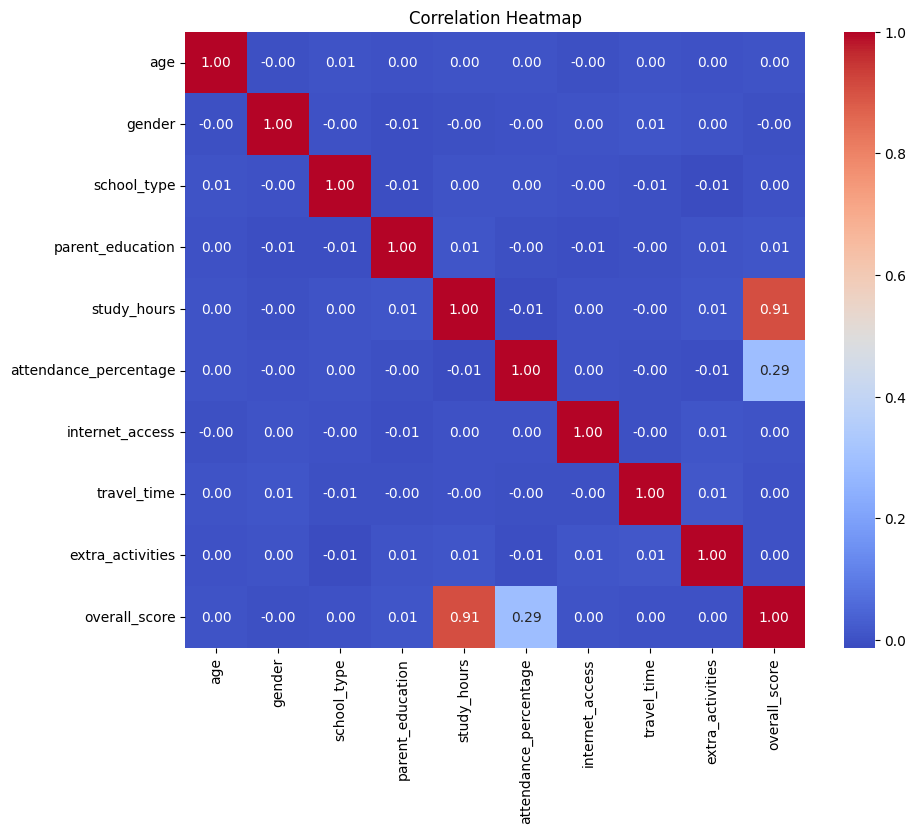

In [107]:
# Here I am focussing on Oerall score only not subject wise score and grades, so I am dropping those columns corresponding to those features.
#I am also dropping student_id column as I don't need it for now, to check correlation
df = df.drop(['math_score','science_score','english_score', 'student_id','final_grade'], axis=1)
corr_table = df.corr()

# Plot heatmap
plt.figure(figsize=(10,8))
sns.heatmap(corr_table, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

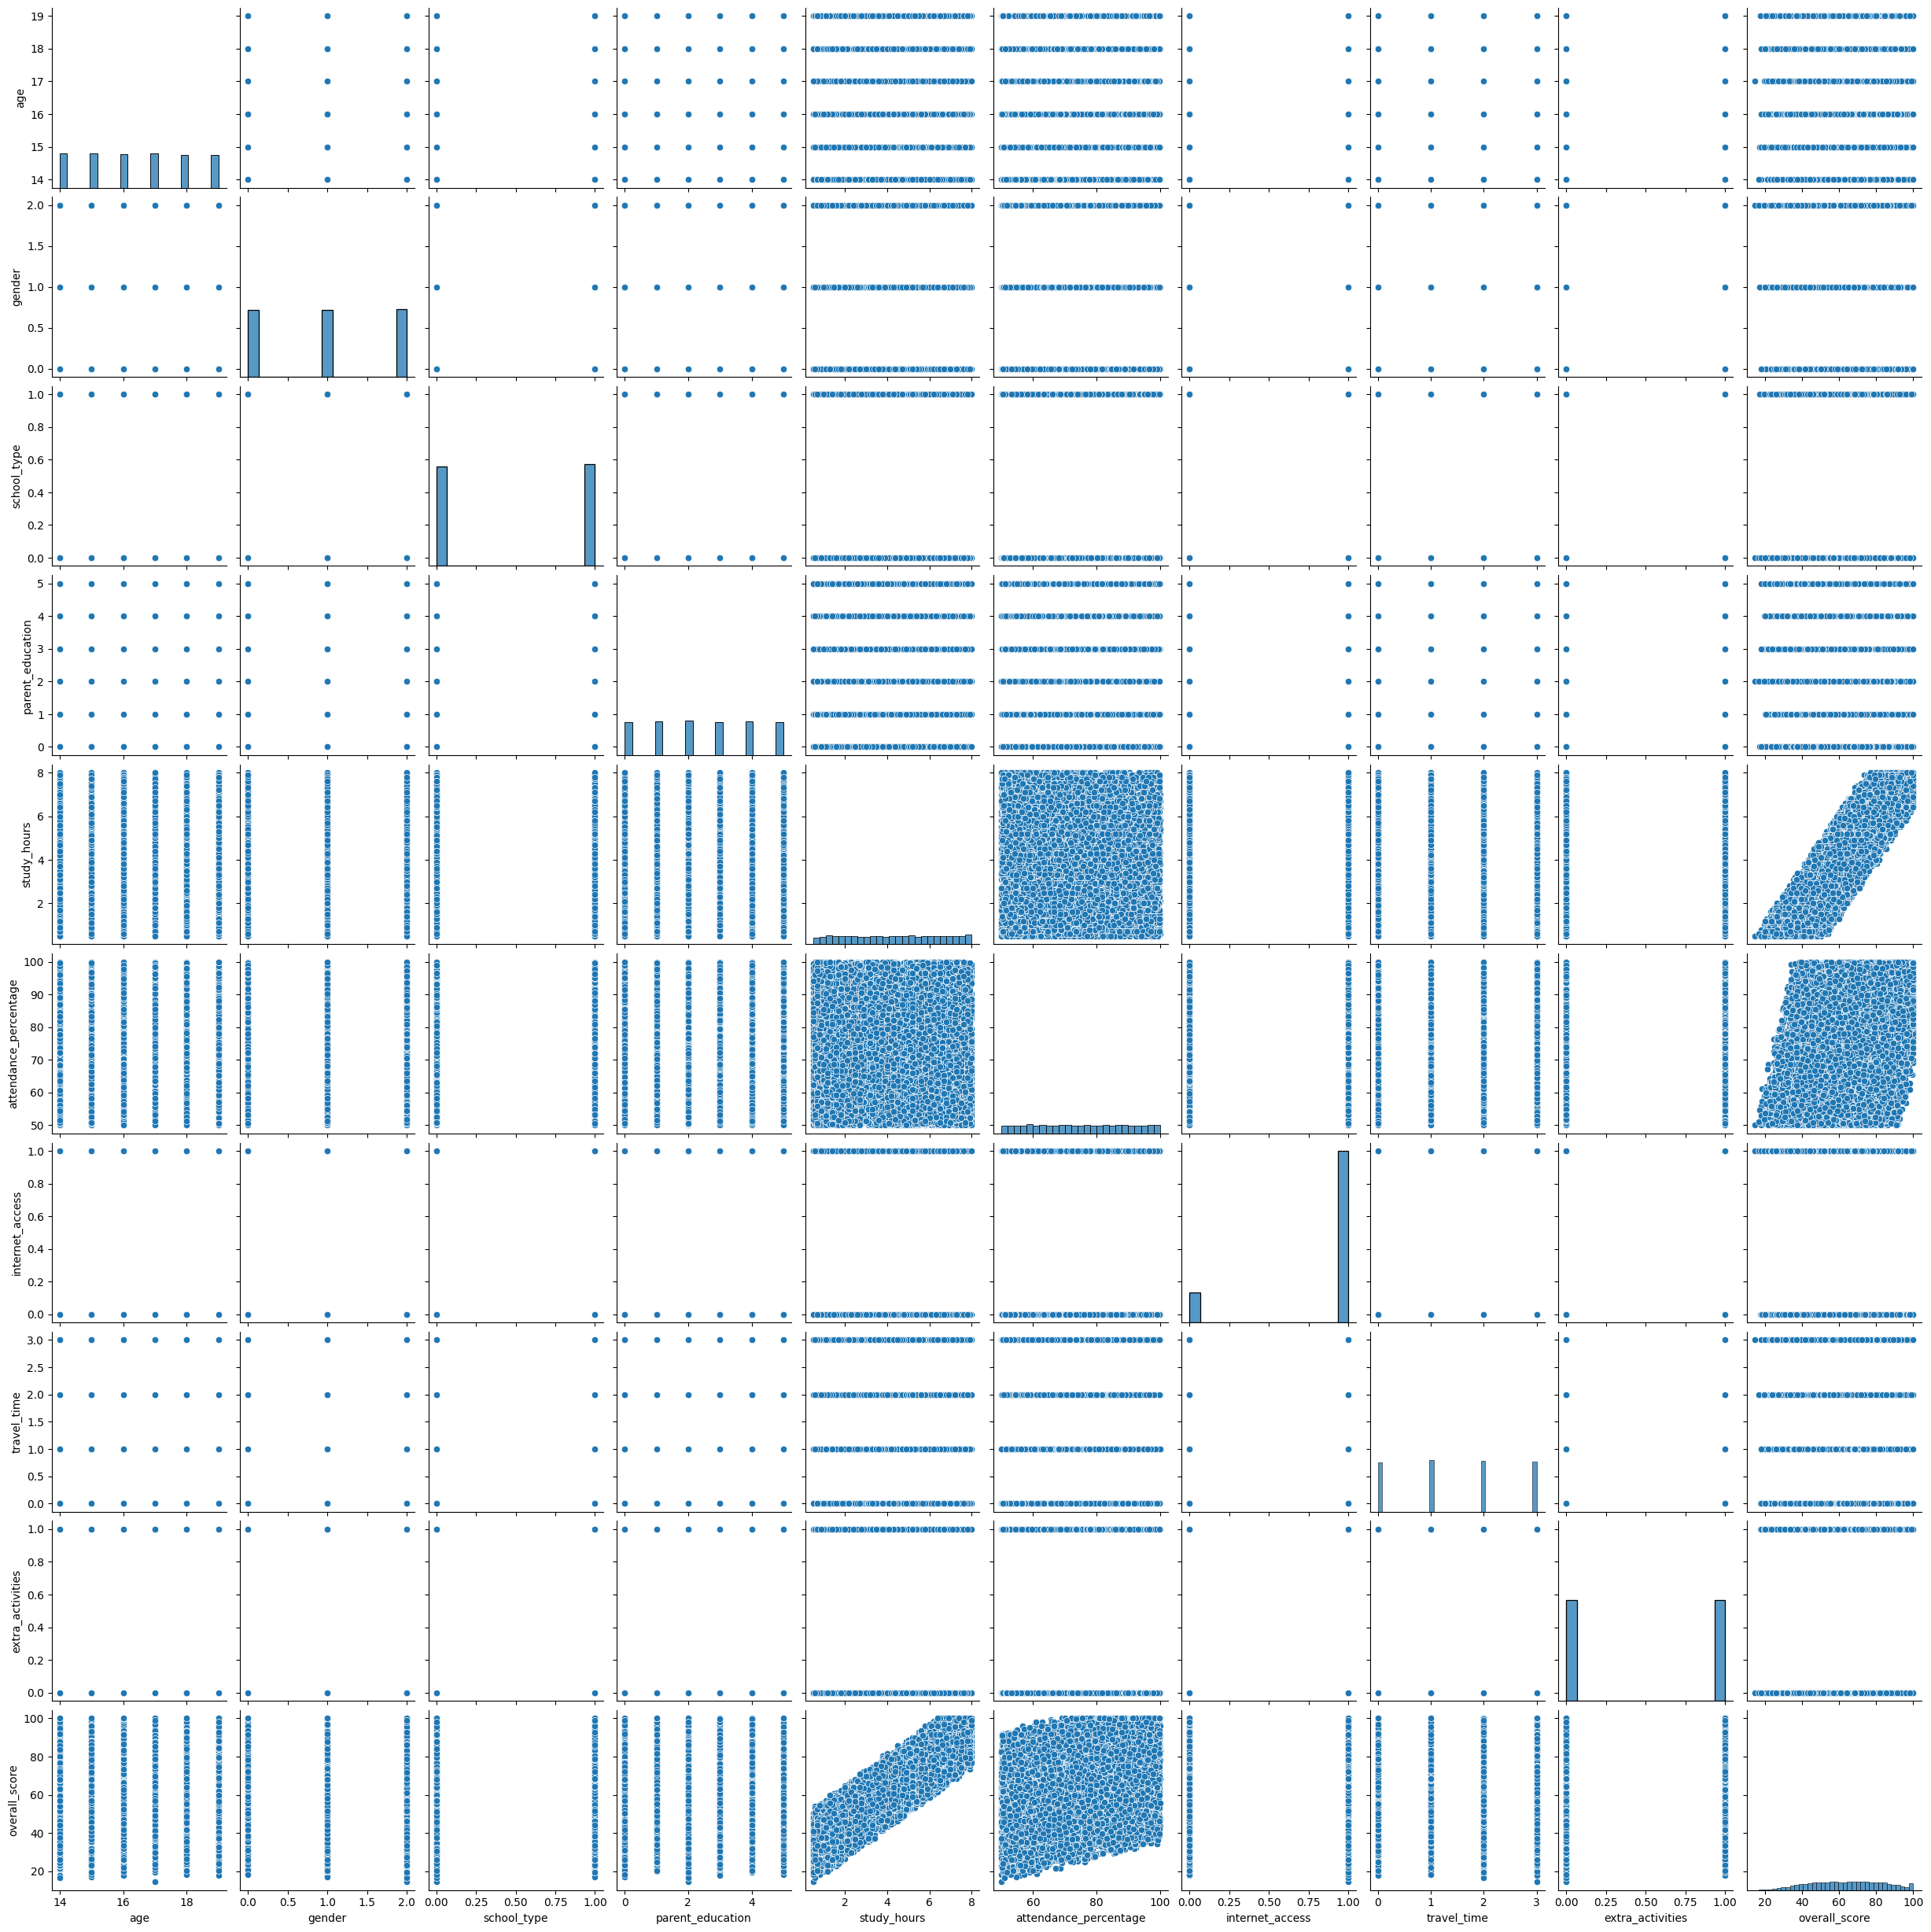

In [108]:
sns.pairplot(df)

Here I am focusing only on the Overall score and it's dependence on study hours and attendance percentage. As we can observe there is no significant correlation between all other features(such as age, gender etc..) and overall score except for study_hours(strong positive correlation), attendance_percentage(slight positive correlation) and parent_education has very light positive impact on student overall performace.

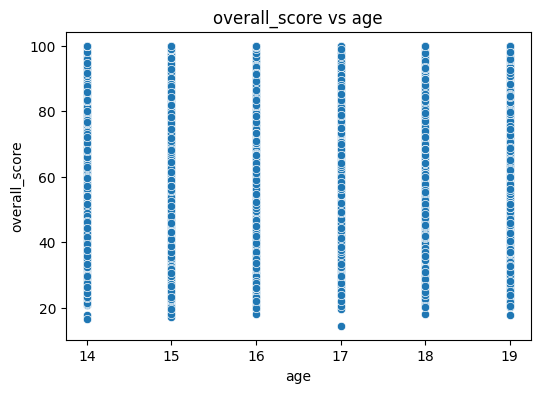

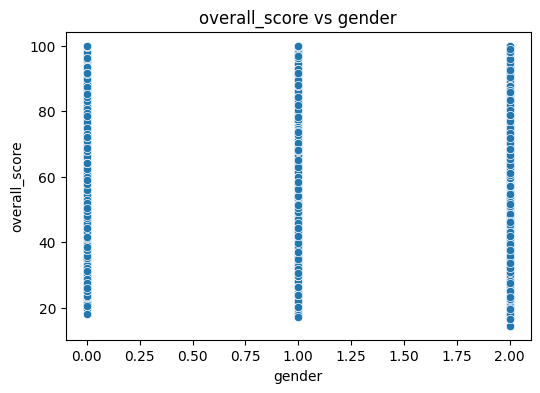

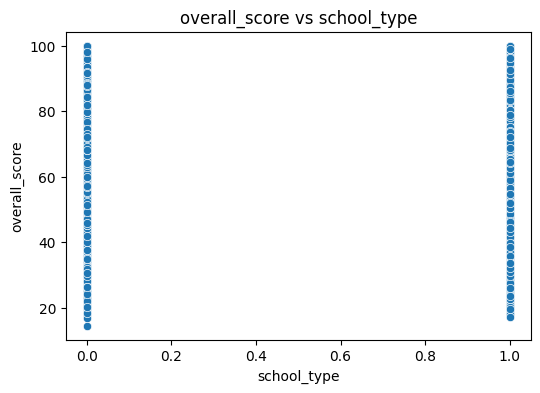

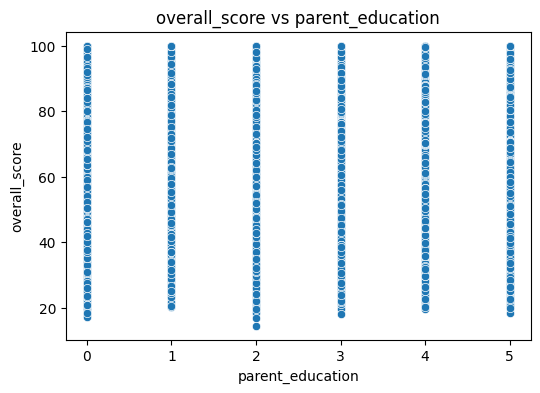

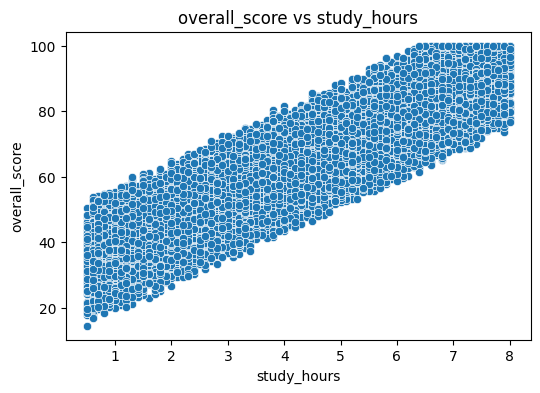

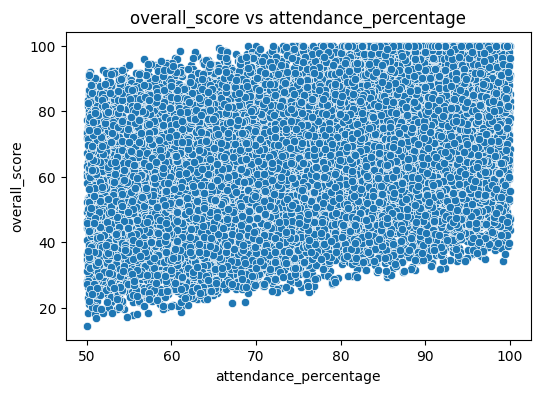

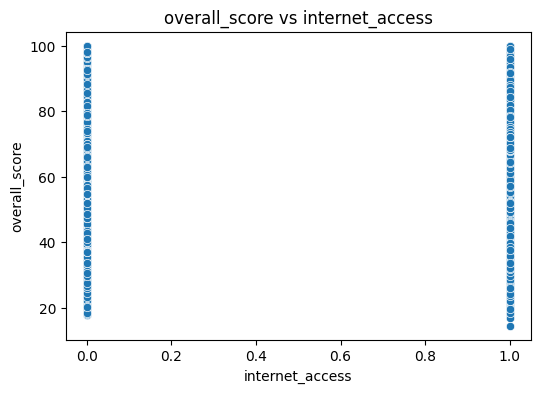

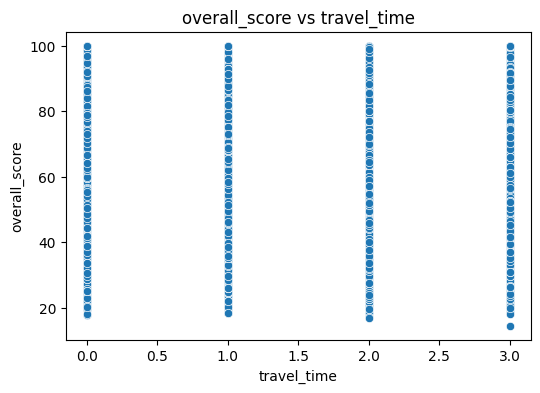

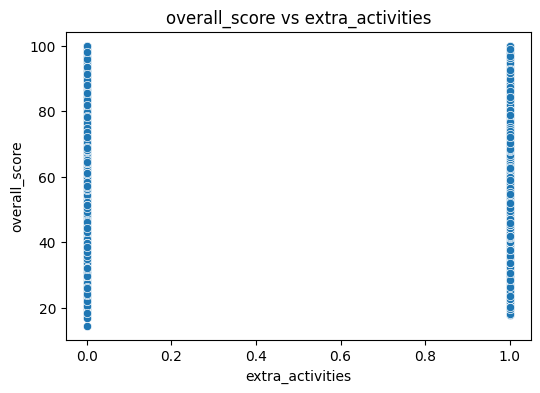

In [109]:
# Assume your target column is named "overall_score"
target = "overall_score"

# Select numeric features except the target
numeric_features = df.select_dtypes(include=["int64", "float64"]).columns.drop(target)

# Loop through features and plot against overall_score
for feature in numeric_features:
    plt.figure(figsize=(6,4))
    sns.scatterplot(x=df[feature], y=df[target])
    plt.title(f"{target} vs {feature}")
    plt.xlabel(feature)
    plt.ylabel(target)
    plt.show()


In [111]:
df.columns

Index(['age', 'gender', 'school_type', 'parent_education', 'study_hours',
       'attendance_percentage', 'internet_access', 'travel_time',
       'extra_activities', 'overall_score'],
      dtype='object')

In [115]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics
y = df['overall_score']
X= df.drop(['age', 'gender', 'school_type', 'internet_access','travel_time', 'extra_activities', 'overall_score' ],axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
model = LinearRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Linear Regression MAE:", metrics.mean_absolute_error(y_test, y_pred))
print("Linear Regression RMSE:", np.sqrt(metrics.mean_squared_error(y_test, y_pred)))

Linear Regression MAE: 4.9679317871272834
Linear Regression RMSE: 5.731548845462653


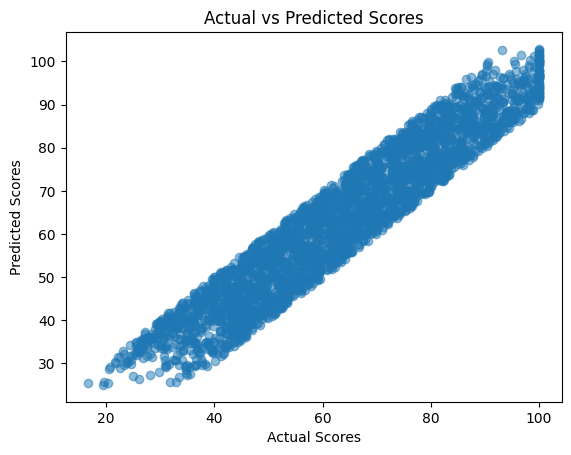

In [121]:
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual Scores")
plt.ylabel("Predicted Scores")
plt.title("Actual vs Predicted Scores")
plt.show()

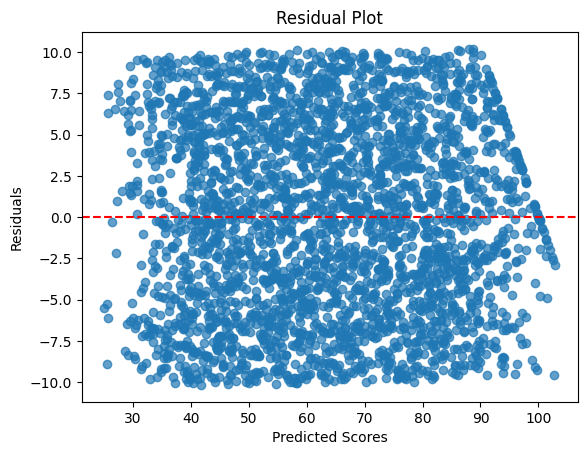

In [122]:
residuals = y_test - y_pred

plt.scatter(y_pred, residuals, alpha=0.7)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Predicted Scores")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

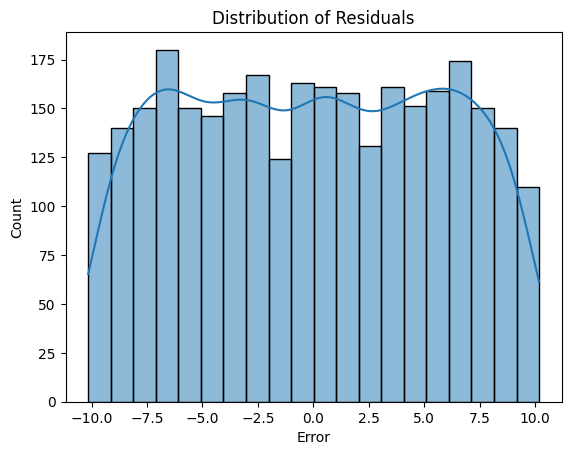

In [123]:
import seaborn as sns

sns.histplot(residuals, bins=20, kde=True)
plt.title("Distribution of Residuals")
plt.xlabel("Error")
plt.show()

Linear Regression MAE: 6.544744184347749
Linear Regression RMSE: 8.00048941592581


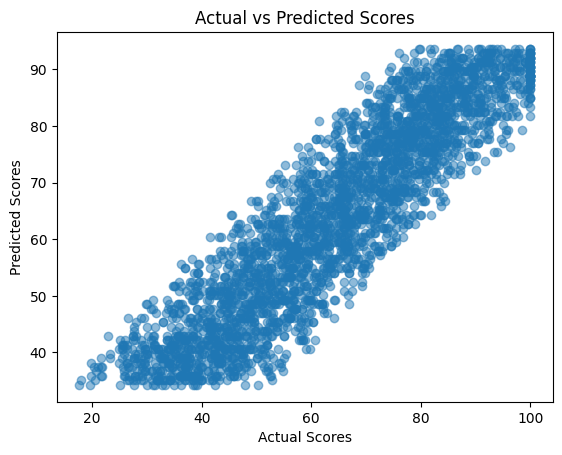

In [125]:
y = df['overall_score']
X= df[['study_hours']]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
model = LinearRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Linear Regression MAE:", metrics.mean_absolute_error(y_test, y_pred))
print("Linear Regression RMSE:", np.sqrt(metrics.mean_squared_error(y_test, y_pred)))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual Scores")
plt.ylabel("Predicted Scores")
plt.title("Actual vs Predicted Scores")
plt.show()

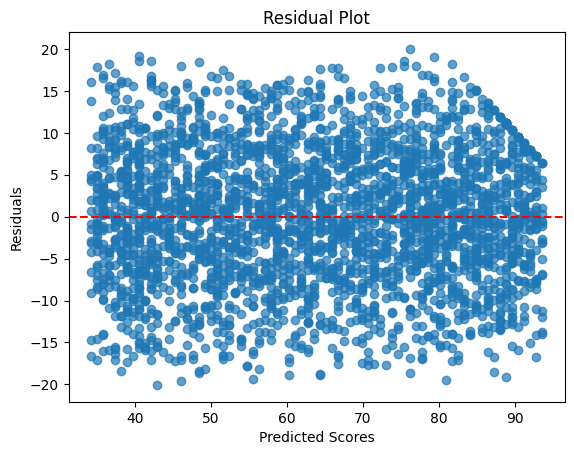

In [126]:
residuals = y_test - y_pred

plt.scatter(y_pred, residuals, alpha=0.7)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Predicted Scores")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()


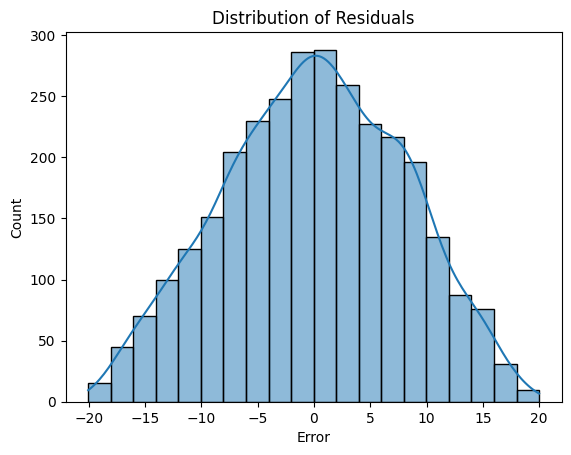

In [127]:
import seaborn as sns

sns.histplot(residuals, bins=20, kde=True)
plt.title("Distribution of Residuals")
plt.xlabel("Error")
plt.show()

Linear Regression MAE: 15.56753741010558
Linear Regression RMSE: 18.191163516840735


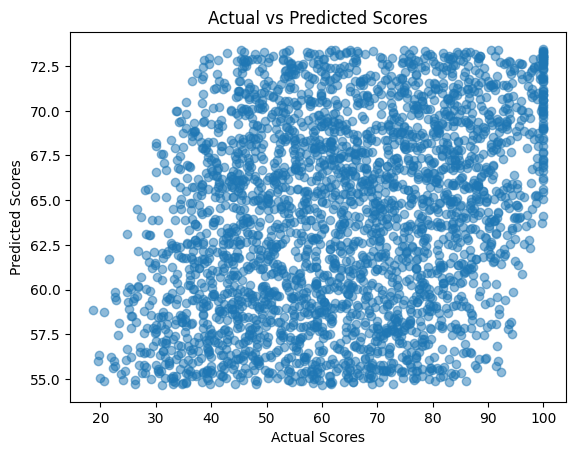

In [135]:
y = df['overall_score']
X= df[['attendance_percentage']]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
model = LinearRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Linear Regression MAE:", metrics.mean_absolute_error(y_test, y_pred))
print("Linear Regression RMSE:", np.sqrt(metrics.mean_squared_error(y_test, y_pred)))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual Scores")
plt.ylabel("Predicted Scores")
plt.title("Actual vs Predicted Scores")
plt.show()

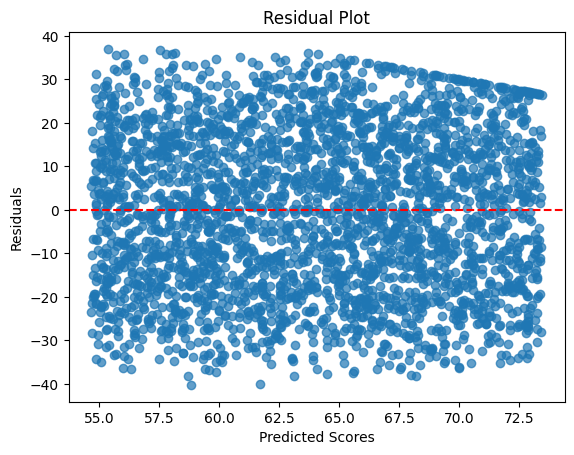

In [136]:
residuals = y_test - y_pred

plt.scatter(y_pred, residuals, alpha=0.7)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Predicted Scores")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

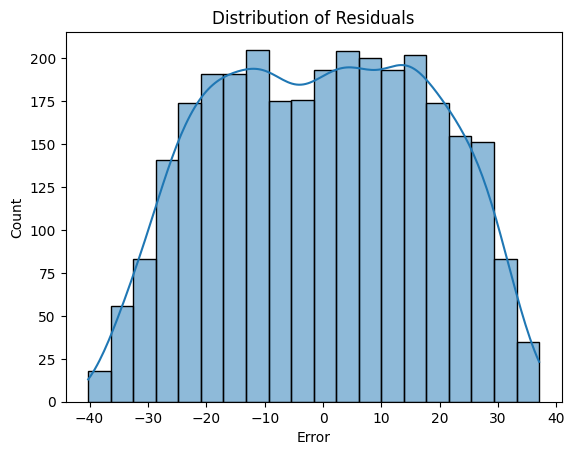

In [137]:
import seaborn as sns

sns.histplot(residuals, bins=20, kde=True)
plt.title("Distribution of Residuals")
plt.xlabel("Error")
plt.show()

Linear Regression MAE: 15.91892681394128
Linear Regression RMSE: 18.83333000468409


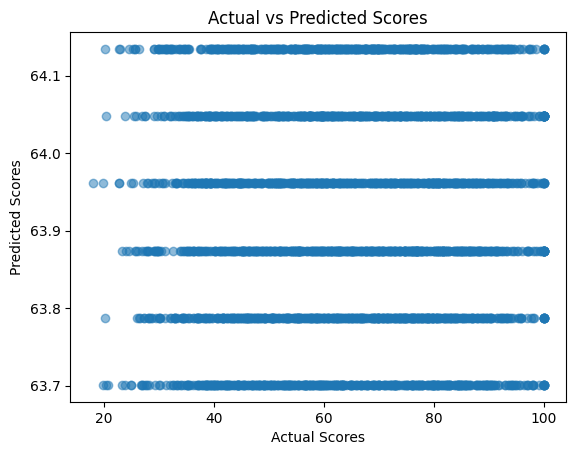

In [138]:
y = df['overall_score']
X= df[['parent_education']]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
model = LinearRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Linear Regression MAE:", metrics.mean_absolute_error(y_test, y_pred))
print("Linear Regression RMSE:", np.sqrt(metrics.mean_squared_error(y_test, y_pred)))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual Scores")
plt.ylabel("Predicted Scores")
plt.title("Actual vs Predicted Scores")
plt.show()

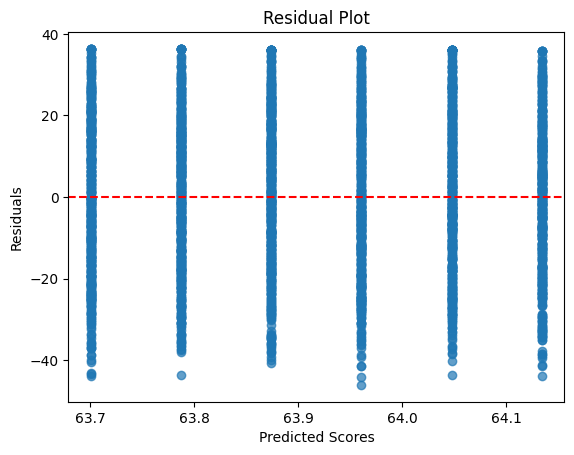

In [139]:
residuals = y_test - y_pred

plt.scatter(y_pred, residuals, alpha=0.7)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Predicted Scores")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

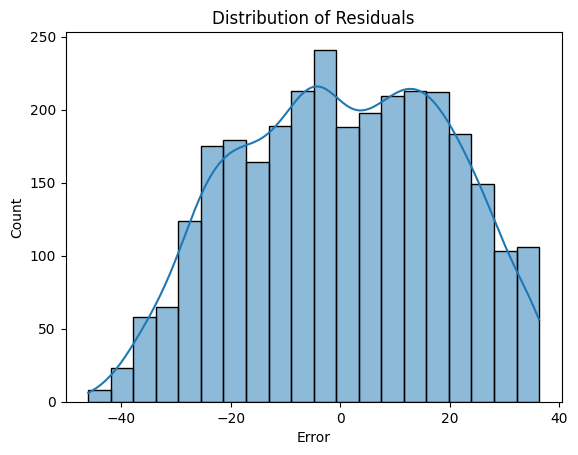

In [140]:
import seaborn as sns

sns.histplot(residuals, bins=20, kde=True)
plt.title("Distribution of Residuals")
plt.xlabel("Error")
plt.show()

In [141]:
y = df["overall_score"]
X = df[["study_hours", "attendance_percentage", "parent_education"]]

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

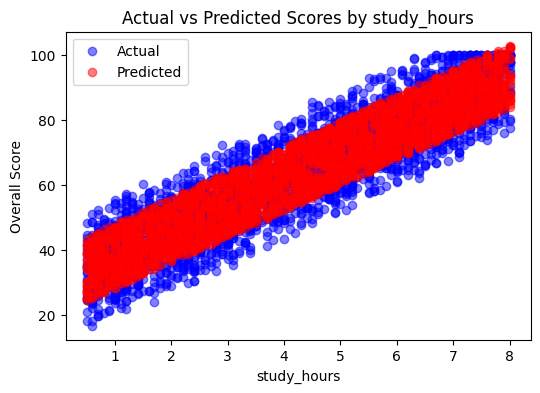

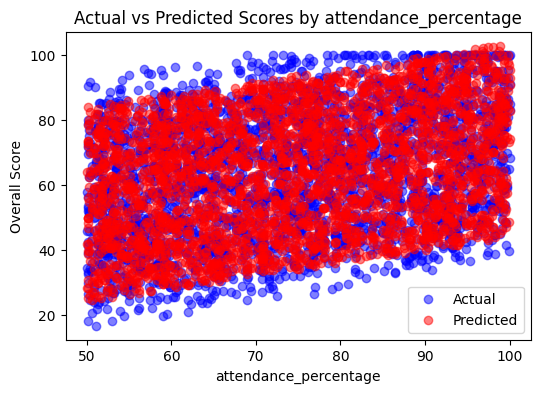

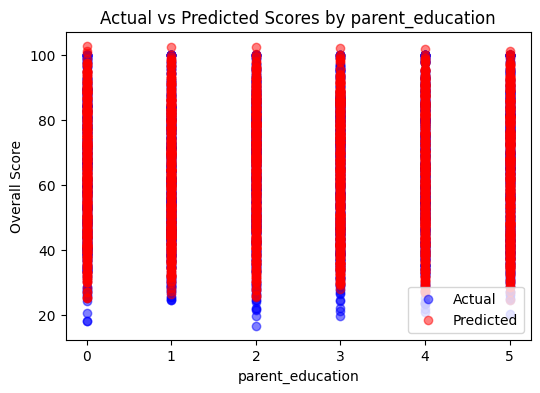

In [134]:
features = ["study_hours", "attendance_percentage", "parent_education"]

for feature in features:
    plt.figure(figsize=(6,4))
    plt.scatter(X_test[feature], y_test, color="blue", alpha=0.5, label="Actual")
    plt.scatter(X_test[feature], y_pred, color="red", alpha=0.5, label="Predicted")
    plt.xlabel(feature)
    plt.ylabel("Overall Score")
    plt.title(f"Actual vs Predicted Scores by {feature}")
    plt.legend()
    plt.show()

In [143]:
y = df["overall_score"]
X = df[["study_hours"]]

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

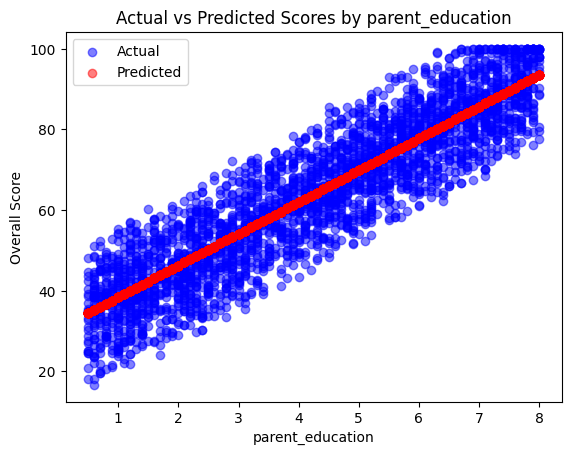

In [144]:
plt.scatter(X_test, y_test, color="blue", alpha=0.5, label="Actual")
plt.scatter(X_test, y_pred, color="red", alpha=0.5, label="Predicted")
plt.xlabel(feature)
plt.ylabel("Overall Score")
plt.title(f"Actual vs Predicted Scores by {feature}")
plt.legend()
plt.show()

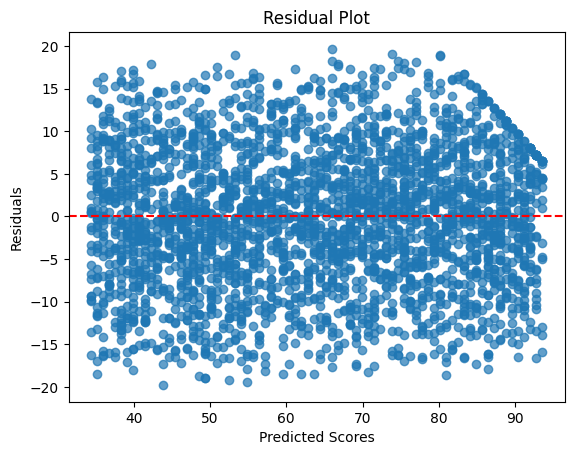

In [147]:
residuals = y_test - y_pred

plt.scatter(y_pred, residuals, alpha=0.7)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Predicted Scores")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

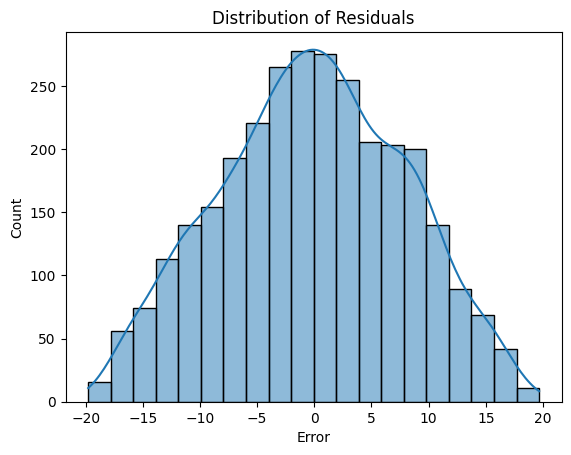

In [148]:
import seaborn as sns

sns.histplot(residuals, bins=20, kde=True)
plt.title("Distribution of Residuals")
plt.xlabel("Error")
plt.show()

#### Low RMSE but spread residuals when I used three features(study_hours, attendance_percentage, parent_education) : The model is numerically accurate but may be overfitting or capturing noise from weaker features.
Using all three features (study_hours, attendance_percentage, parent_education)  
→ The model has more information, so it reduces overall error (lower RMSE).

→ But residuals may look “spread out” because the model is fitting multiple dimensions at once. The residual plot can show heteroscedasticity (uneven variance) or patterns that are harder to interpret visually.

#### Higher RMSE but clean residuals when i used single strong feature (study_hours): The model is simpler and interpretable, but less precise overall.
→ The model is simpler, so residuals look more “normal” (random scatter around zero).

→ But because it ignores other explanatory variables, the overall error is higher (RMSE increases).

In [149]:
print("Linear Regression MAE:", metrics.mean_absolute_error(y_test, y_pred))
print("Linear Regression RMSE:", np.sqrt(metrics.mean_squared_error(y_test, y_pred)))
r2 = metrics.r2_score(y_test, y_pred)
print("Linear Regression R²:", r2)

Linear Regression MAE: 6.603452157013174
Linear Regression RMSE: 8.075500424292274
Linear Regression R²: 0.8233937086905013


#### Conclusion: Study hours is the dominant factor influencing student scores. Attendance and parent education add marginal improvements but reduce residual clarity.

study_hours alone explains a large proportion of student performance, with an R² of 0.82. This means that 82% of the variance in overall scores can be accounted for by study hours, making it the single most powerful predictor in the dataset.

When we combined study_hours with attendance_percentage and parent_education, the model achieved a lower RMSE (numerically more accurate), but the residual plots revealed more spread and complexity. This highlights the trade‑off between accuracy and interpretability: